# Exploration approfondie de la base d'apprentissage

In [1]:
import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

from eda import *

In [2]:
# Configuration
FILE_PATH = "../data_finale/train.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [3]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

In [4]:
print("Types des variables")

analyser_types(df_base)

Types des variables
Analyse des types de variables
Variables numériques   : 146
Variables catégorielles: 4


Analyse des valeurs manquantes
                         nb_missing    pct
contrat_jours_restants         1704  21.02
market_value_in_eur             705   8.70
market_value_in_eur_nor         705   8.70
nation                            2   0.02

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


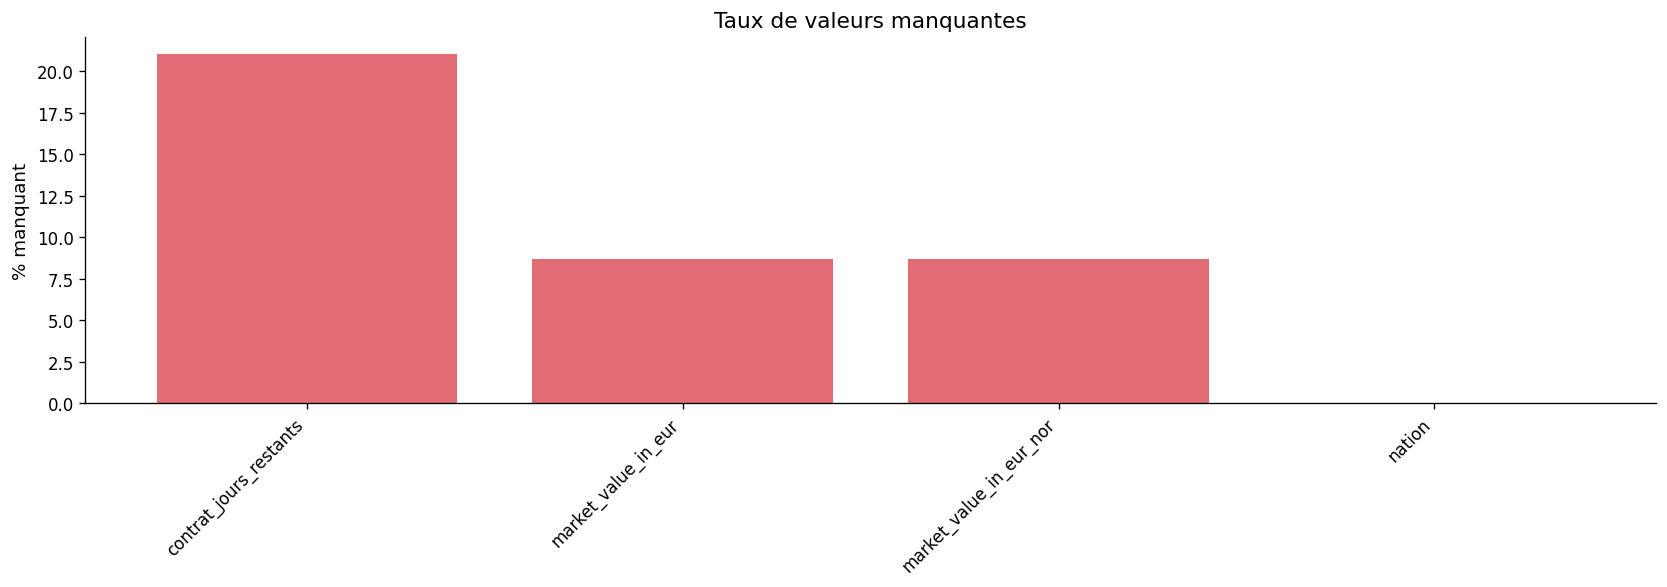

In [5]:
analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          7,400
mean      10,863,649
std       15,551,861
min           50,000
25%        2,000,000
50%        5,000,000
75%       14,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Skewness : 3.24
Kurtosis : 15.61

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


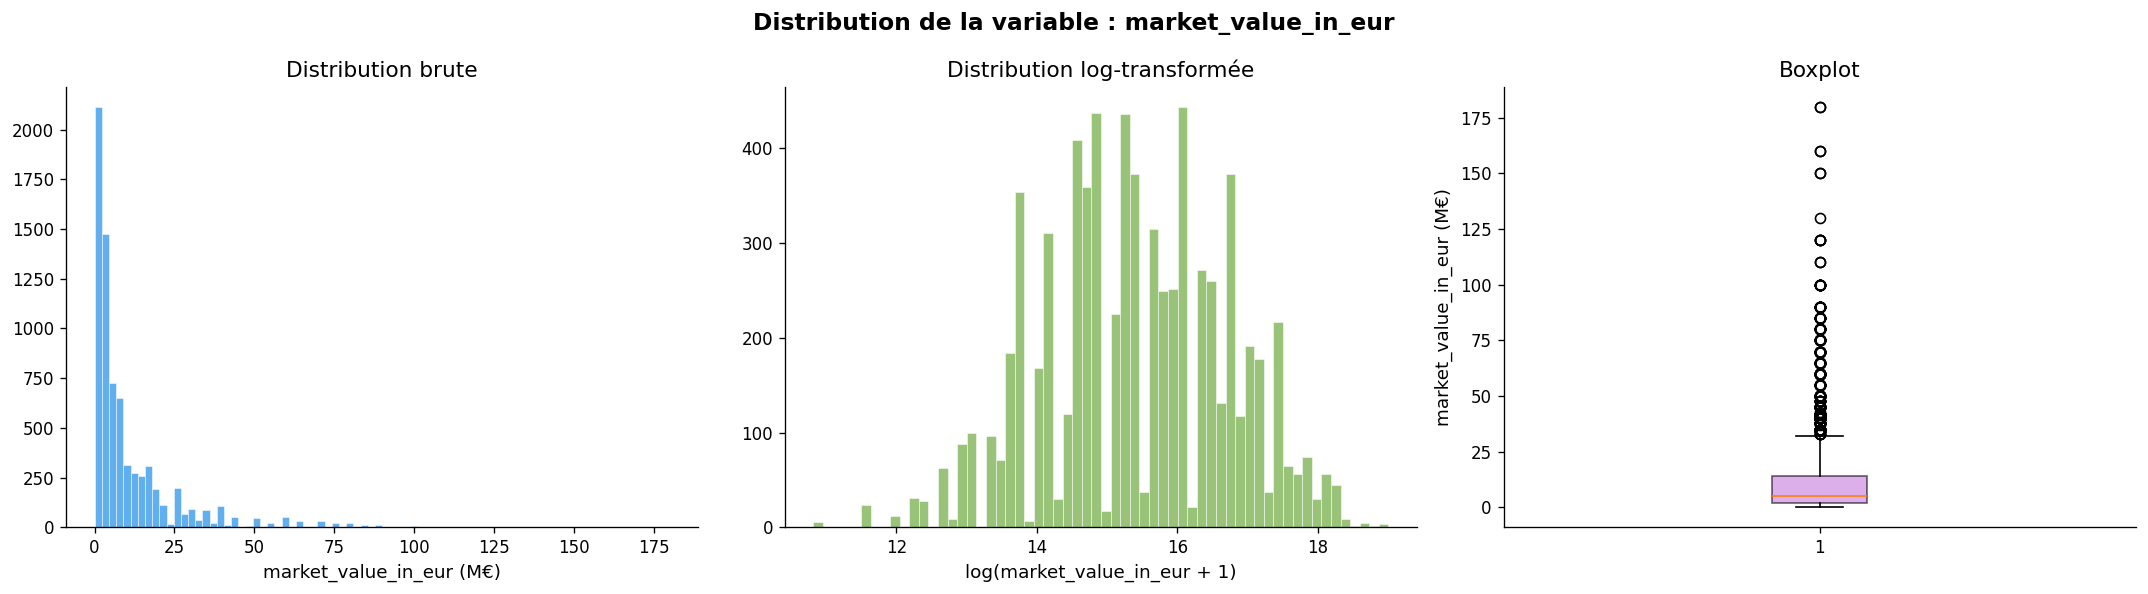

In [6]:
analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


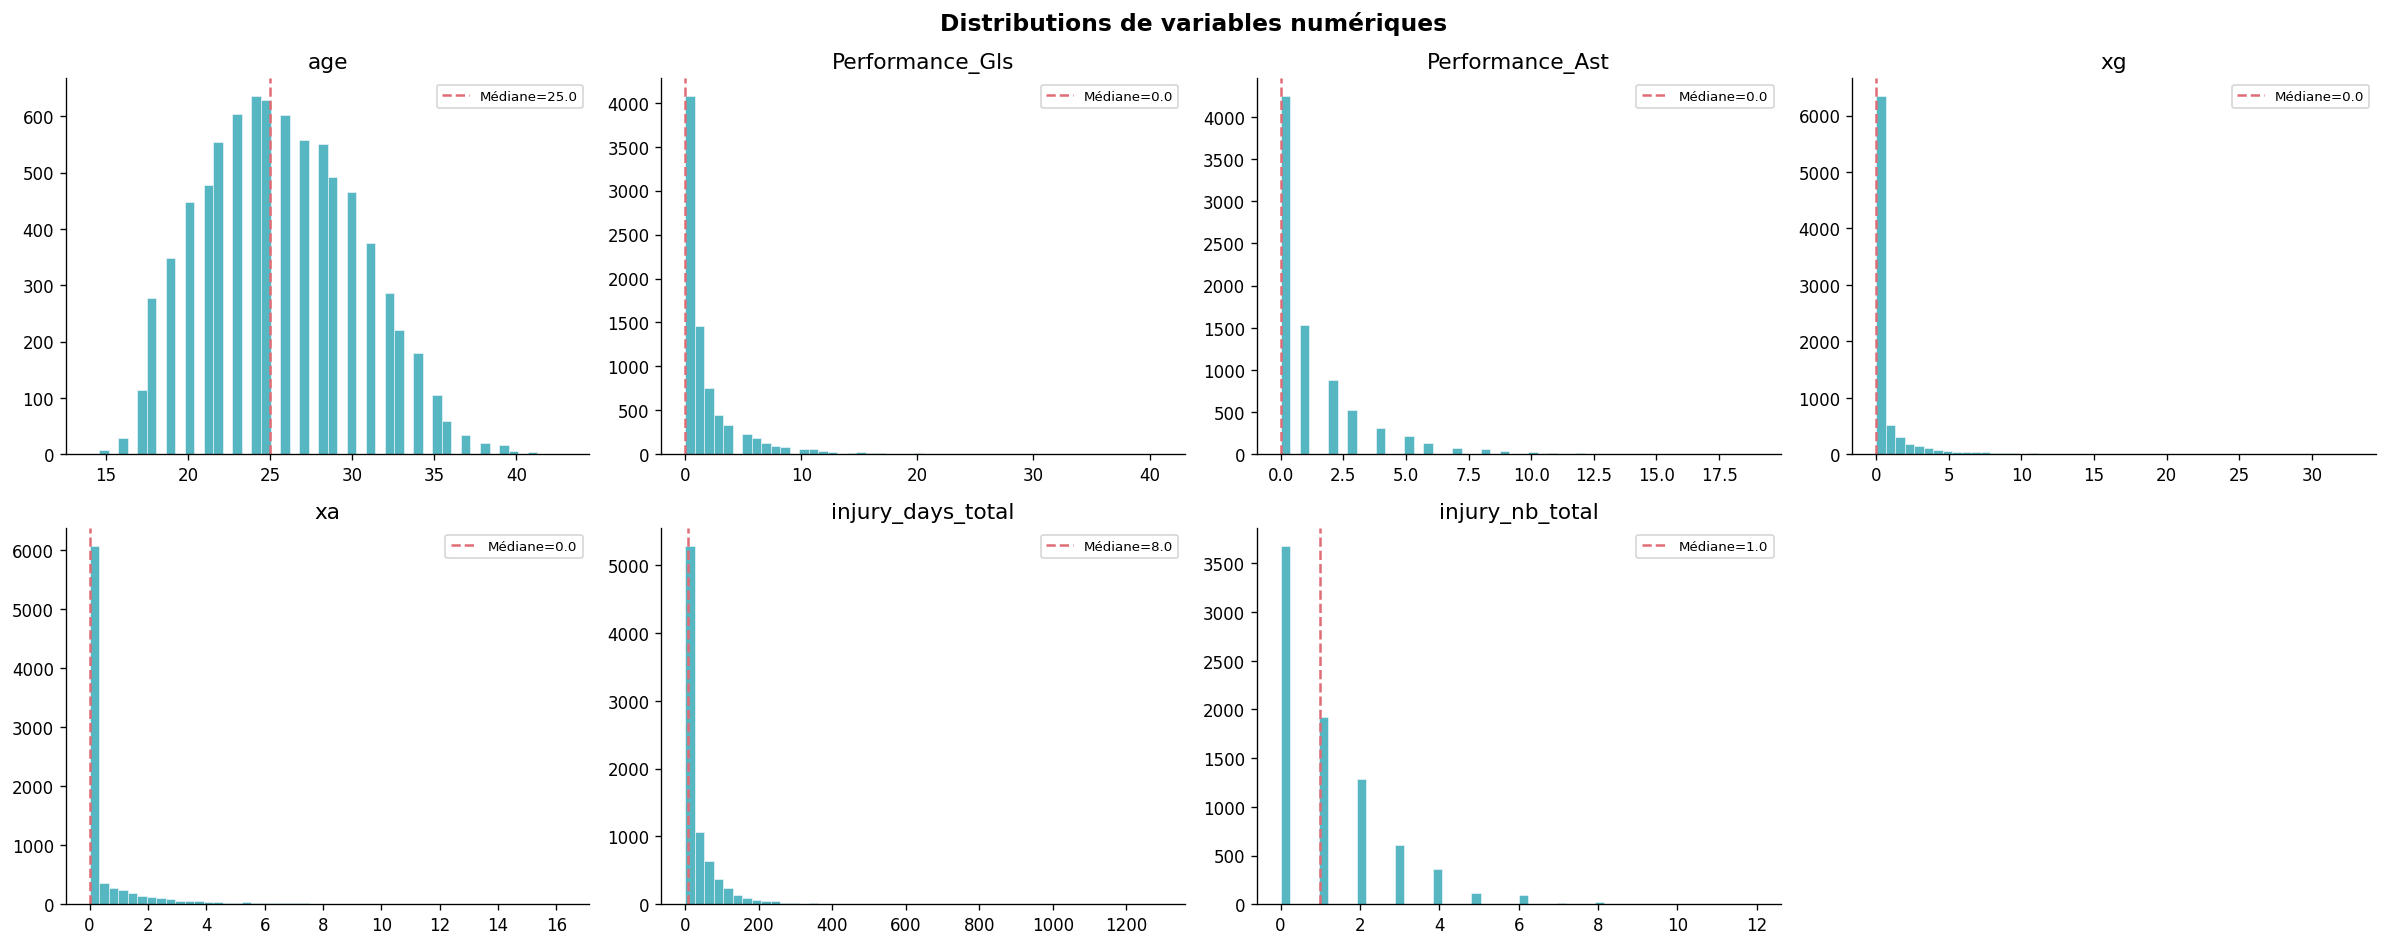

In [7]:
analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

Analyse des variables catégorielles

league (5 modalités encodées) :
ITA-Serie A           1723
ESP-La Liga           1700
FRA-Ligue 1           1679
ENG-Premier League    1547
GER-Bundesliga        1456

players_top_nations.png sauvegardé


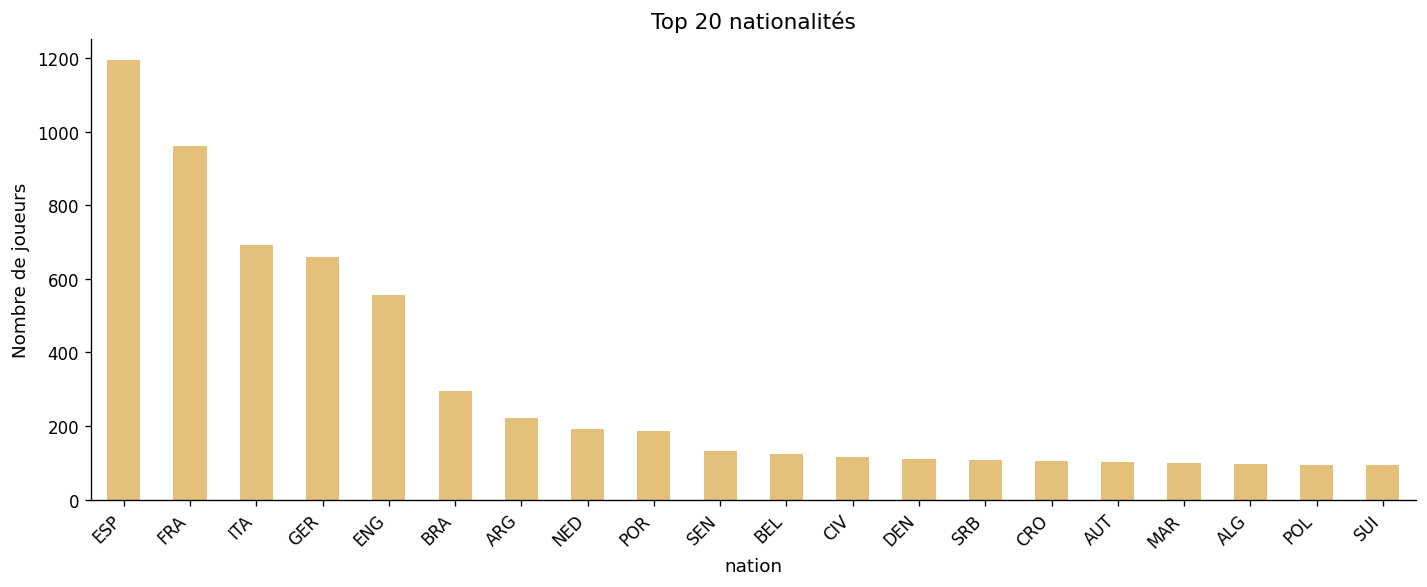

league.png sauvegardé


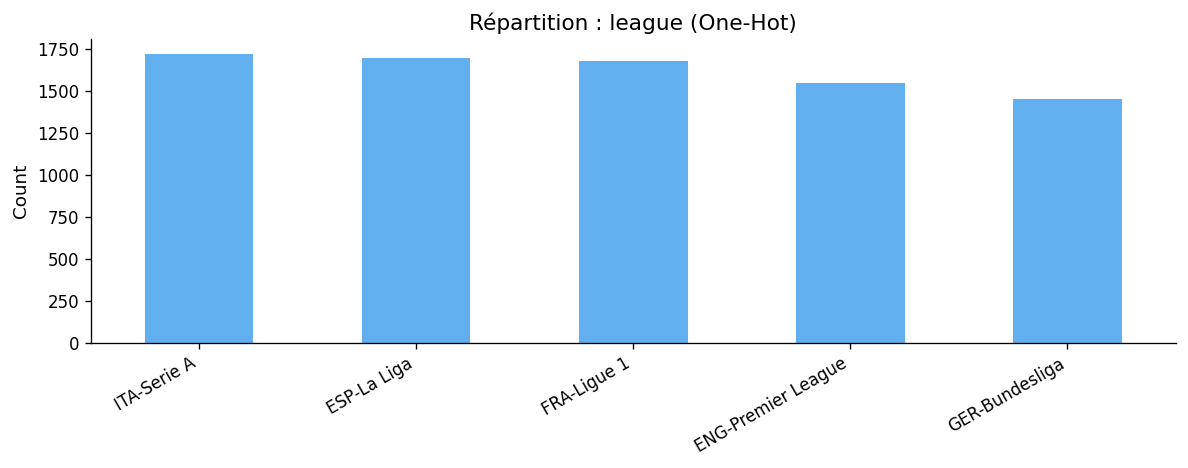

vm_par_league.png sauvegardé


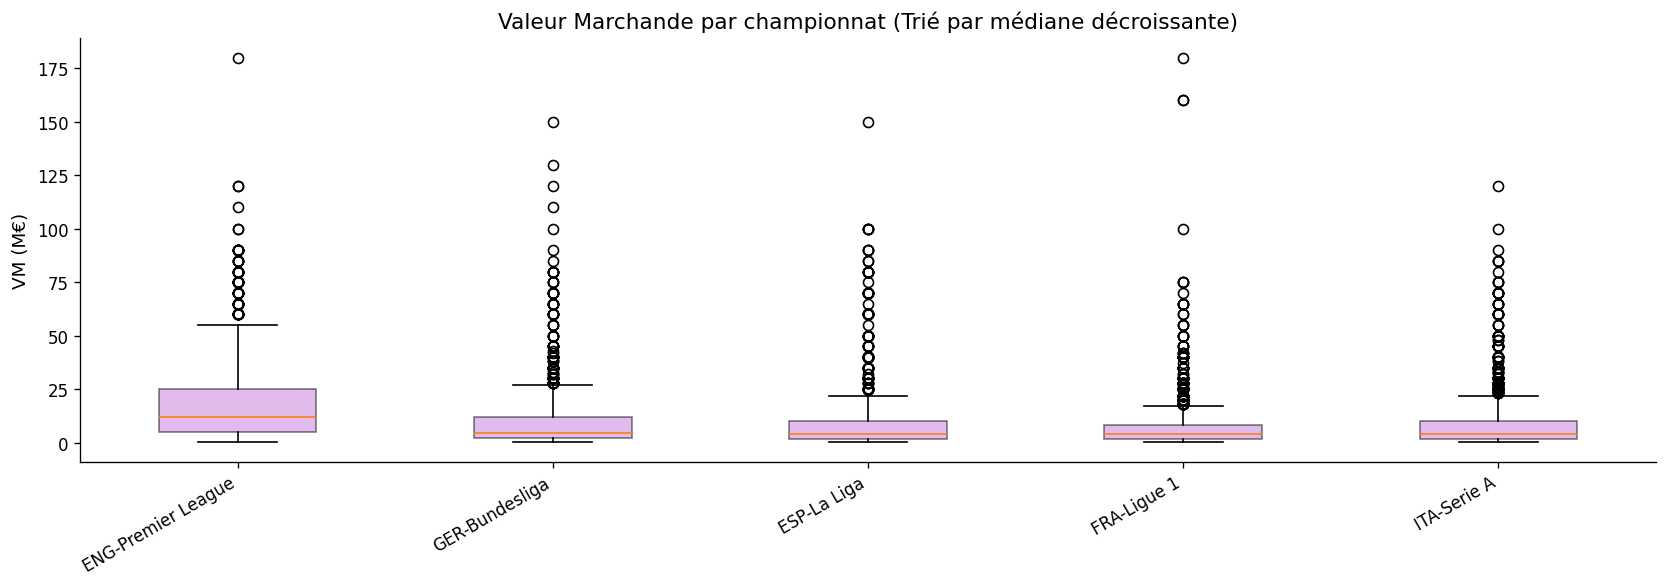

In [8]:
analyser_variables_categorielles(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

In [9]:
analyser_outliers(df_base)

Détection des outliers
         variable  outliers_IQR  pct_IQR  outliers_Zscore  total
              age            12      0.1               12   8105
  Performance_Gls           804      9.9              194   8105
  Performance_Ast           392      4.8              183   8105
               xg          1402     17.3              194   8105
               xa          1505     18.6              238   8105
injury_days_total           670      8.3              161   8105
  injury_nb_total           141      1.7              141   8105


Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
Performance_Gls                 0.478122
Performance_Ast                 0.459103
xg                              0.264033
xa                              0.257751
injury_nb_total                 0.110383
injury_days_total               0.026405
age                            -0.158765

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


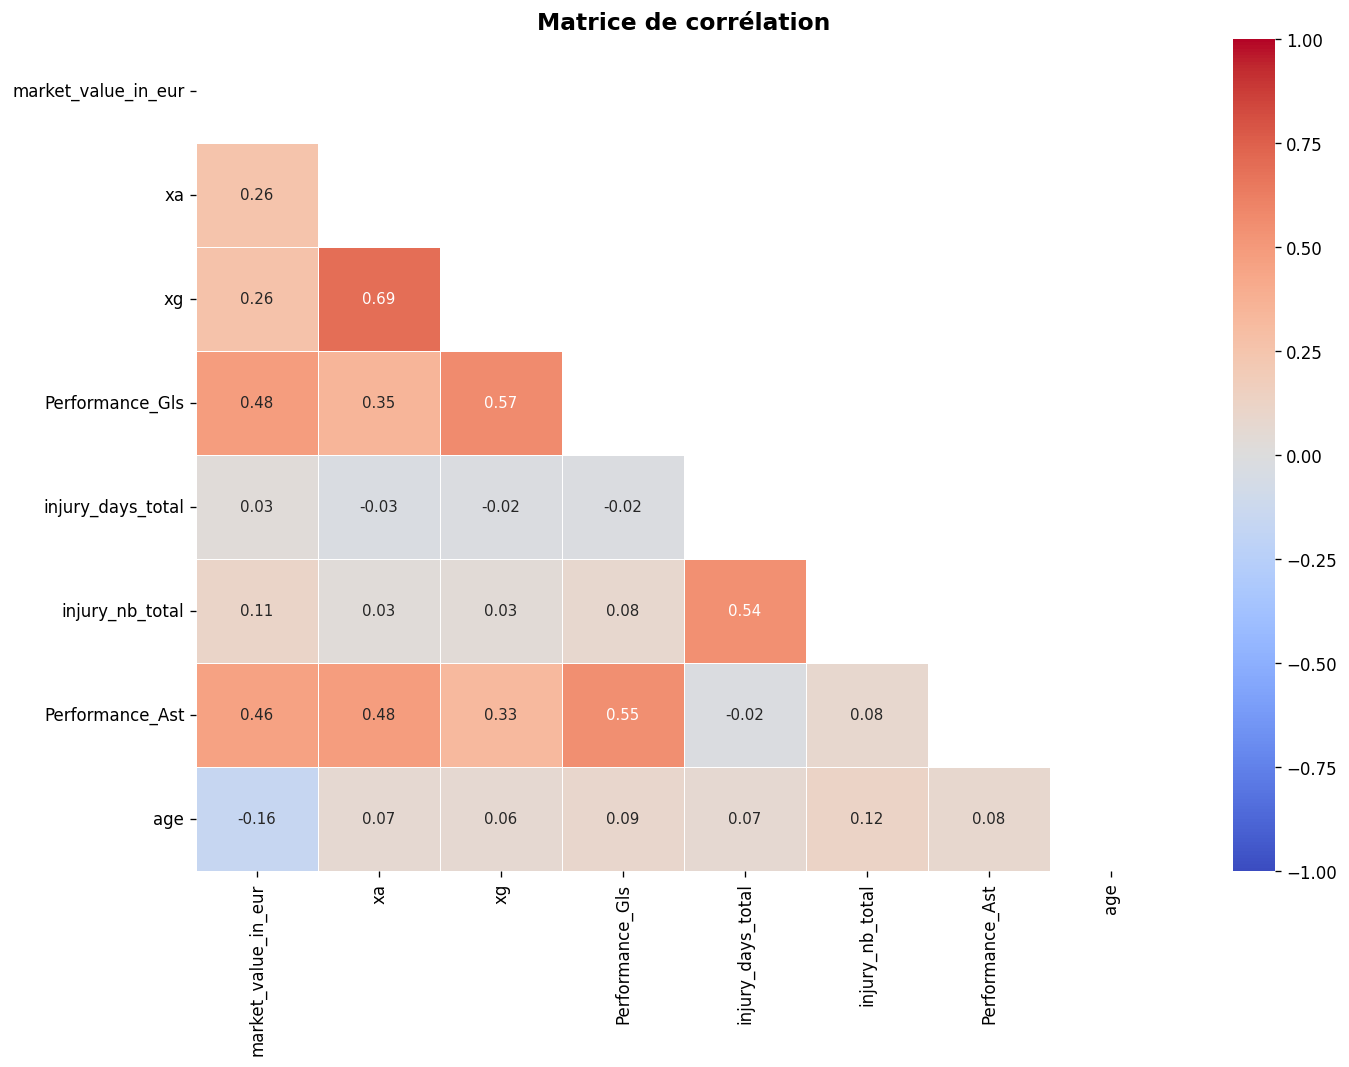


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
market_value_in_eur_nor    1.000000
Team Success_onG           0.576379
Standard_Sh_nor            0.493242
Standard_Sh                0.493242
Standard_SoT_nor           0.485508
Standard_SoT               0.485508
Performance_G-PK           0.483573
Performance_Gls            0.478122
Performance_Gls_nor        0.478122
Performance_Ast_nor        0.459103
Performance_Ast            0.459103
Playing Time_90s           0.385602
Playing Time_Starts        0.383827
Playing Time_Starts_nor    0.383827
Performance_Fld            0.355357
Playing Time_MP_nor        0.354606
Playing Time_MP            0.354606
Team Success_PPM_nor       0.334244
Team Success_PPM           0.334244
Starts_Compl               0.305440


In [10]:
analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

## Segmentation par poste

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


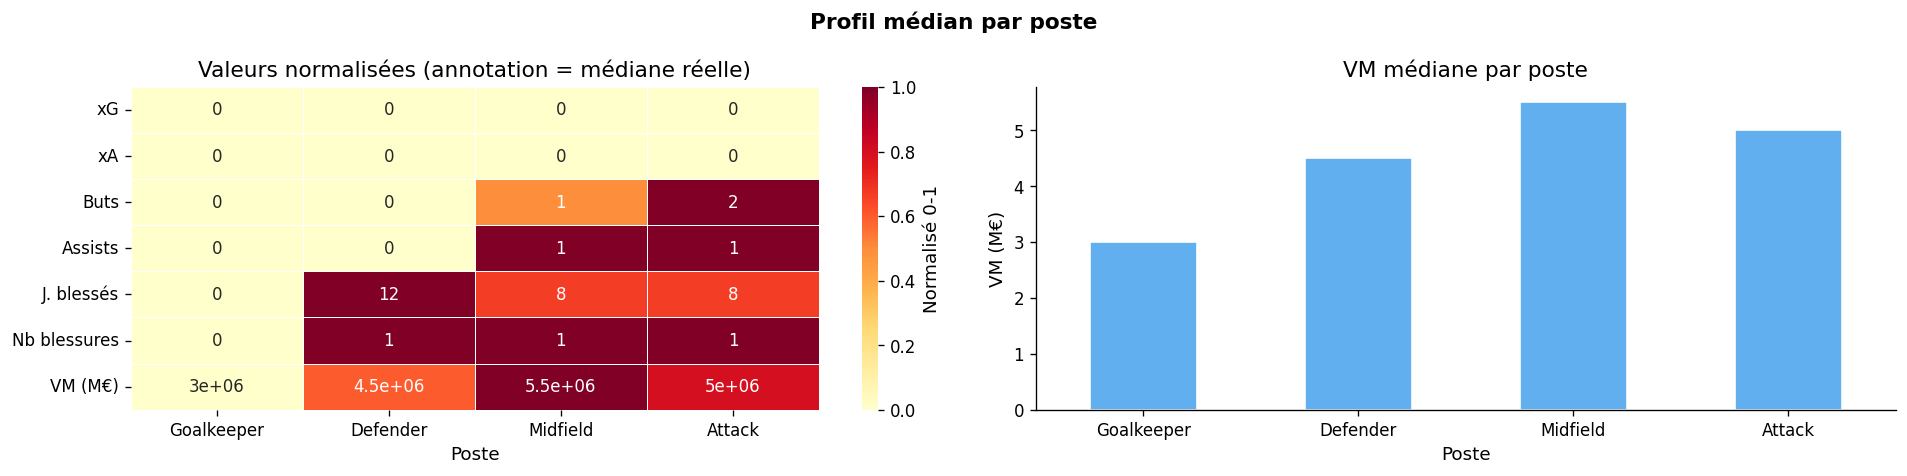

In [11]:
analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


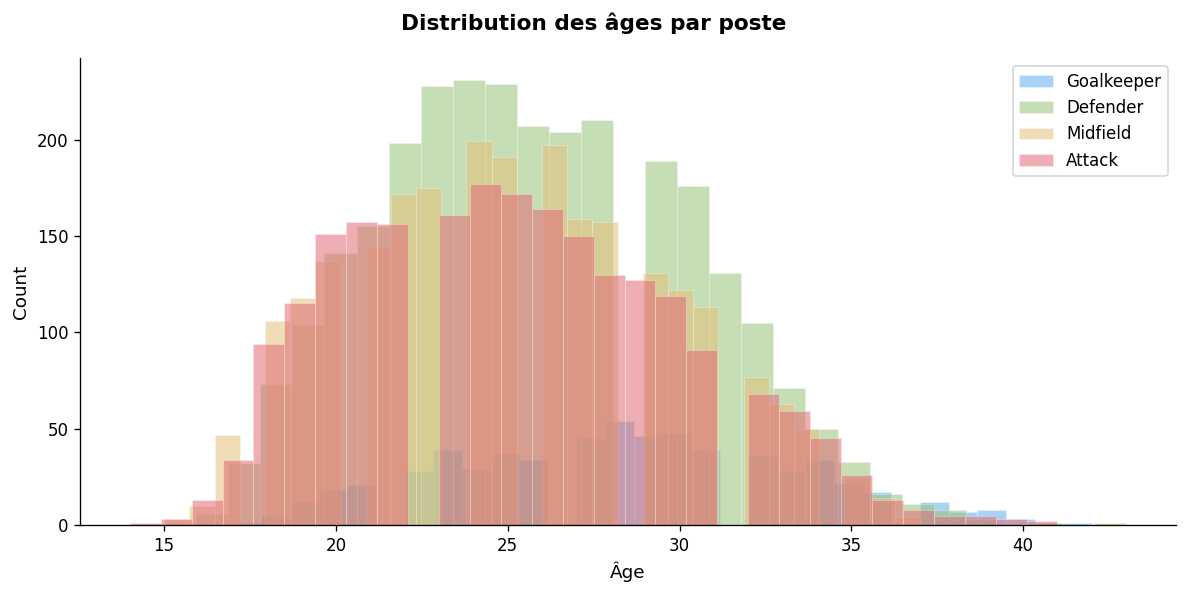


Âge médian par poste
position
Goalkeeper    28.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [12]:
analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : VM médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


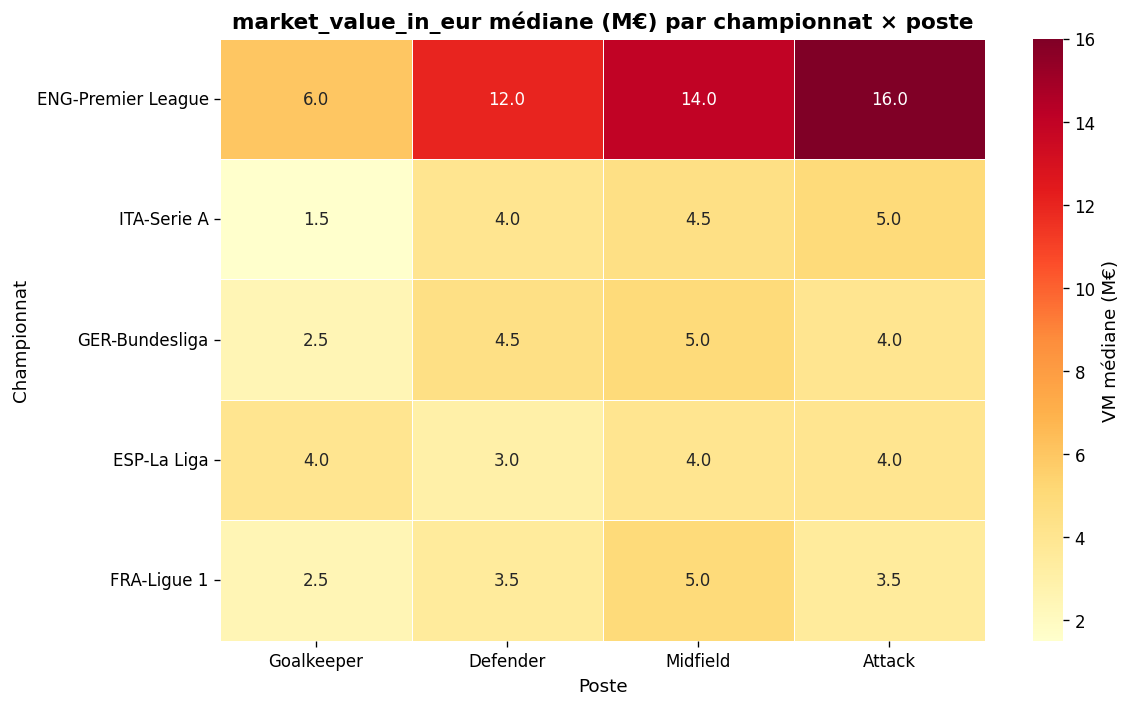

In [13]:
analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la distribution par championnat

Violin plot sauvegardé sous : ..\outputs\eda\feature_engineered_violin_league.png


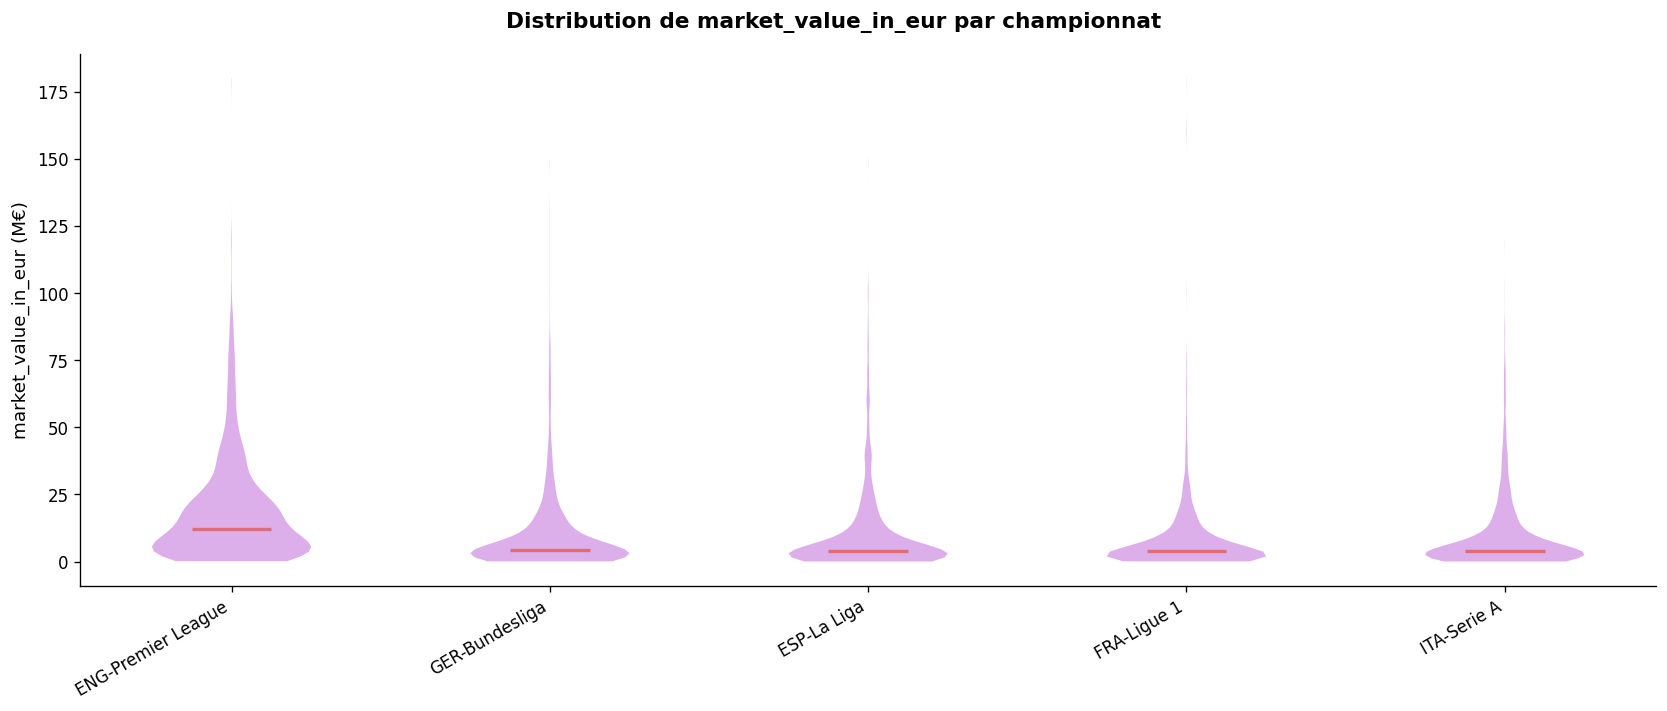

In [14]:
analyser_distribution_violin_league(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 22 observations

Top 20 des joueurs les plus chers
           player position  age  market_value_in_eur        xg  Performance_Gls  injury_days_total
   Erling Haaland   Attack   22                180.0 32.761400               36               24.0
    Kylian Mbappé   Attack   24                180.0  0.000000               29               14.0
    Kylian Mbappé   Attack   22                160.0  0.000000               27               39.0
    Kylian Mbappé   Attack   23                160.0  0.000000               28               17.0
  Vinicius Júnior   Attack   22                150.0  0.000000               10                8.0
   Erling Haaland   Attack   21                150.0  0.000000               22               99.0
   Erling Haaland   Attack   20                130.0  0.000000               27               10.0
   Victor Osimhen   Attack   24        

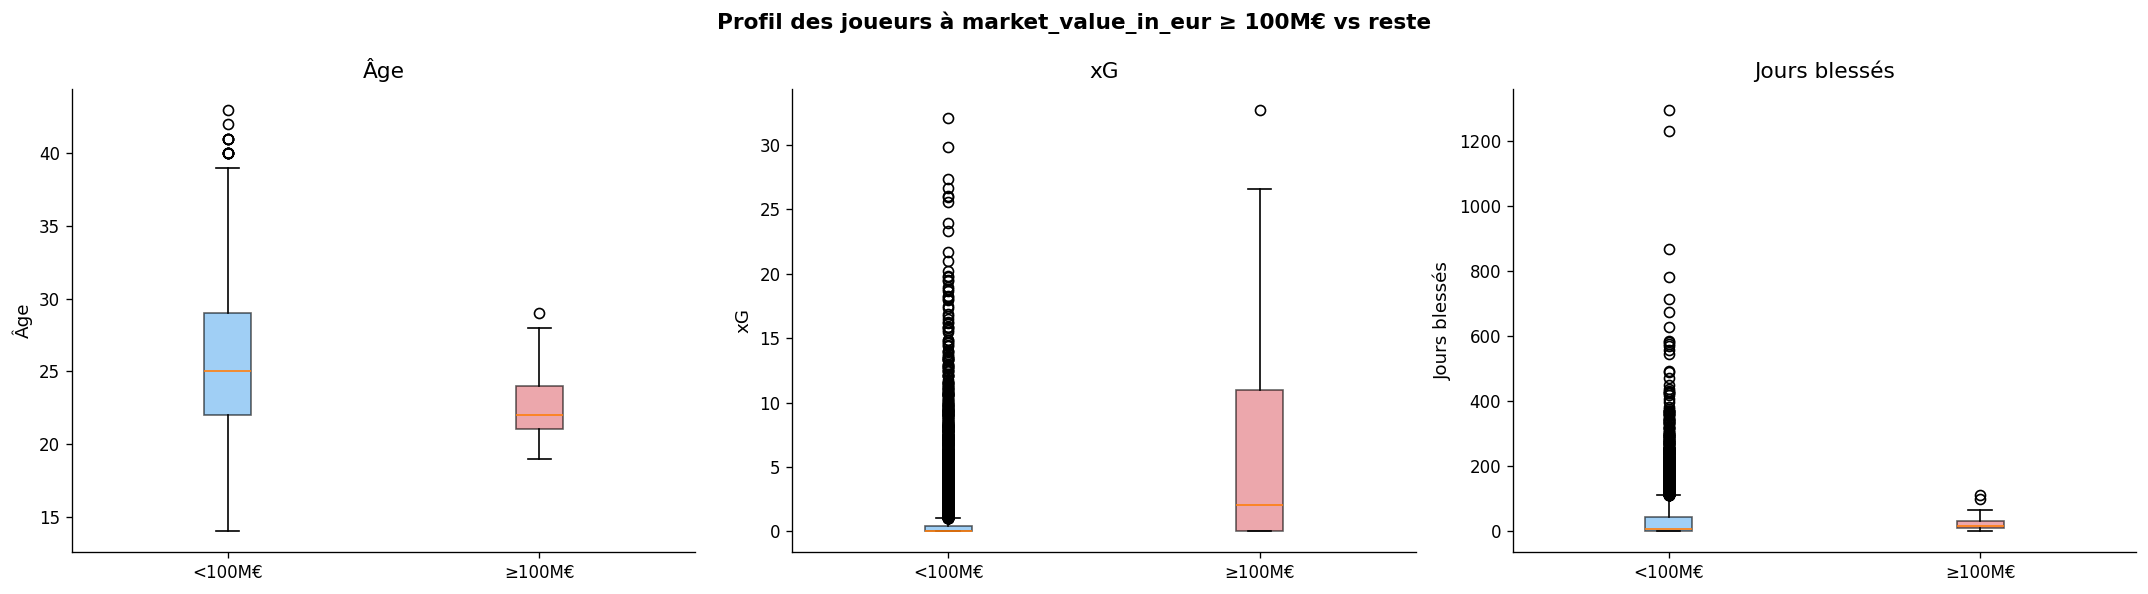

In [15]:
analyser_profil_outliers(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

In [16]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (8105/8105 lignes analysées) :
  Cohérents (diff = 0)           : 7,786
  Diff ≤ 1 jour                  : 7,786
  Diff > 1 jour (anomalie)       : 319
  Diff max                       : 1229 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.589601        2505
2021                  5.0     10.671248        2419
2022                  5.0     11.328877        2476

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


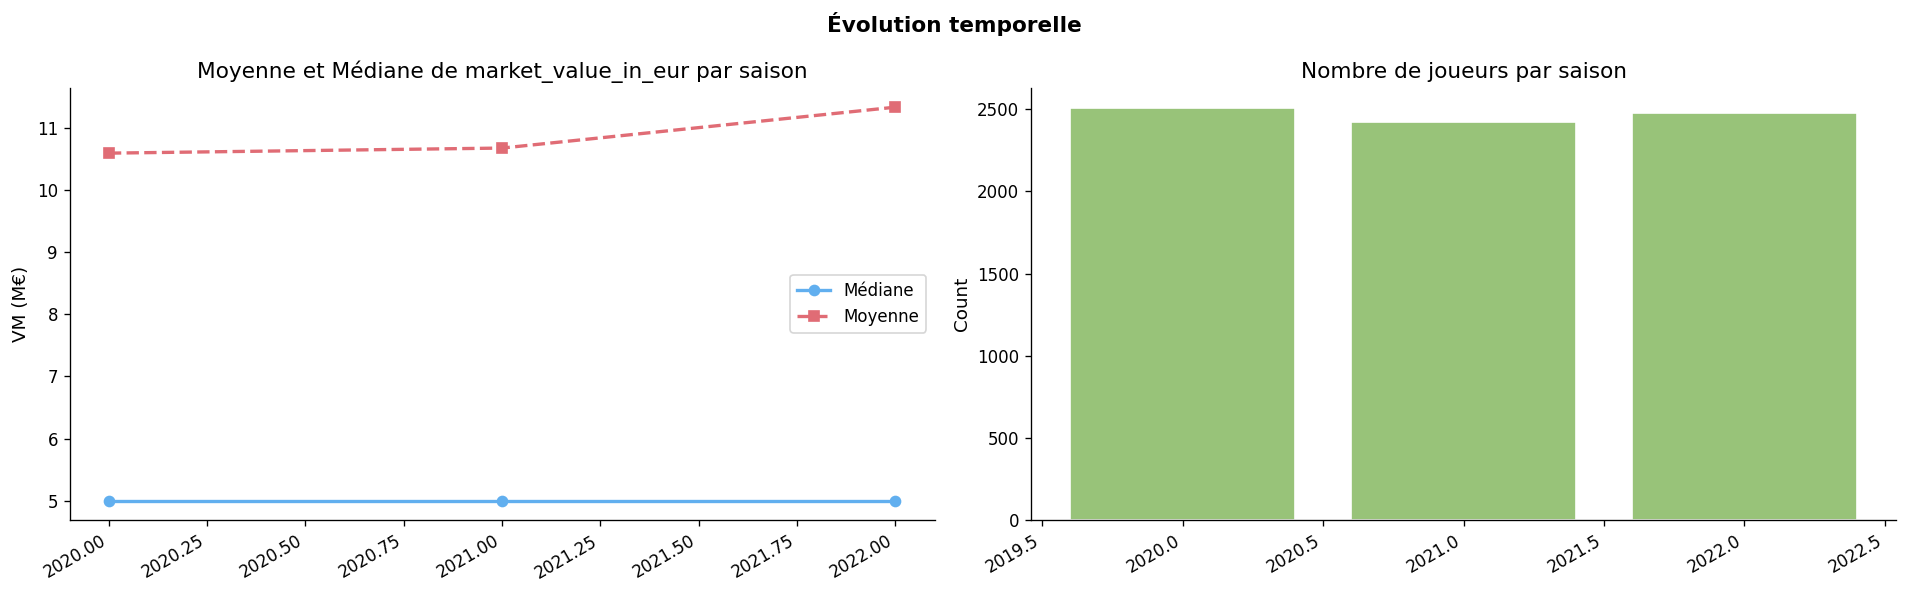

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.589601,2505
2021,5.0,10.671248,2419
2022,5.0,11.328877,2476


In [17]:
analyser_evolution_temporelle_saison(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Démarrage de l'analyse du cycle de vie financier...
8103 observations valides trouvées pour l'analyse graphique.


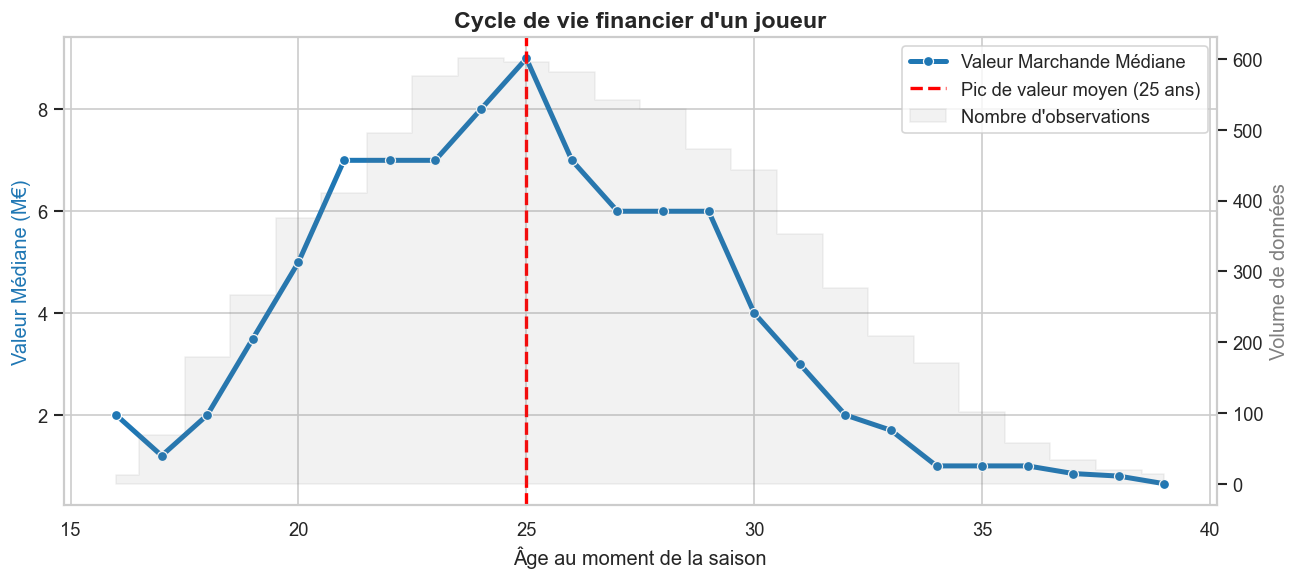


Graphique généré avec succès.


In [18]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


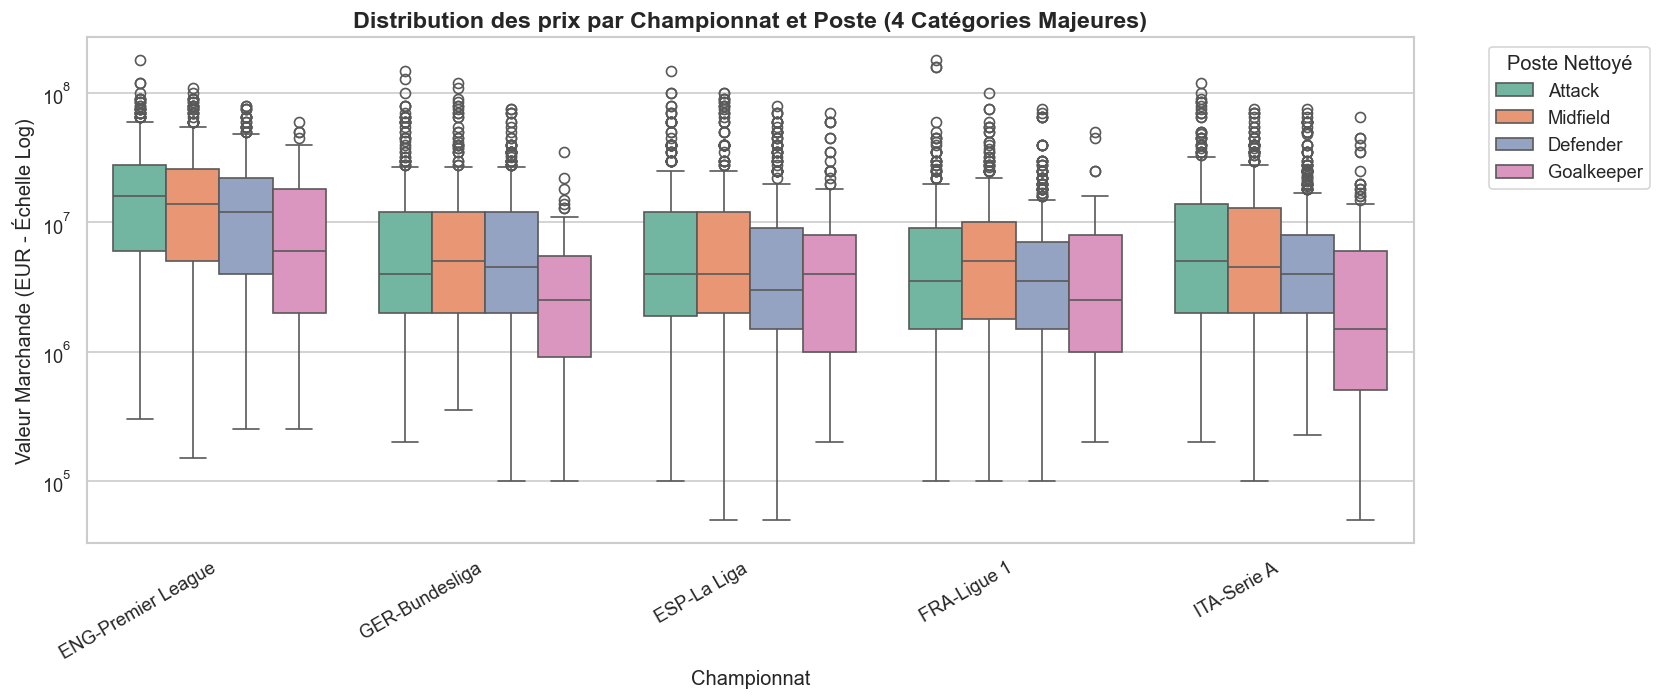


Boxplot généré avec succès.


In [19]:
analyser_distribution_prix_ligue_poste(df_base)

In [20]:
# On détecte les colinéarités
colinearites = detecter_top_colinearites(df_base, top_n=30)

# On affiche le tableau
display(colinearites)

Extraction du Top 30 des colinéarités (hors variables normalisées)...


,Variable_A,Variable_B,Correlation
0,Playing Time_90s,Playing Time_Starts,0.994
1,Performance_G-PK,Performance_Gls,0.978
2,Performance_L,Performance_GA,0.974
3,Performance_Saves,Performance_GA,0.971
4,Performance_PKatt,Performance_PK,0.969
5,pos_GK,Performance_Save%,0.967
6,injury_musculaire_nb_m,injury_musculaire_nb_d,0.961
7,Standard_SoT,Standard_Sh,0.958
8,injury_cheville_pied_nb_m,injury_cheville_pied_nb_d,0.955
9,Performance_CS,Performance_W,0.951


Analyse des variables les plus explicatives pour : market_value_in_eur


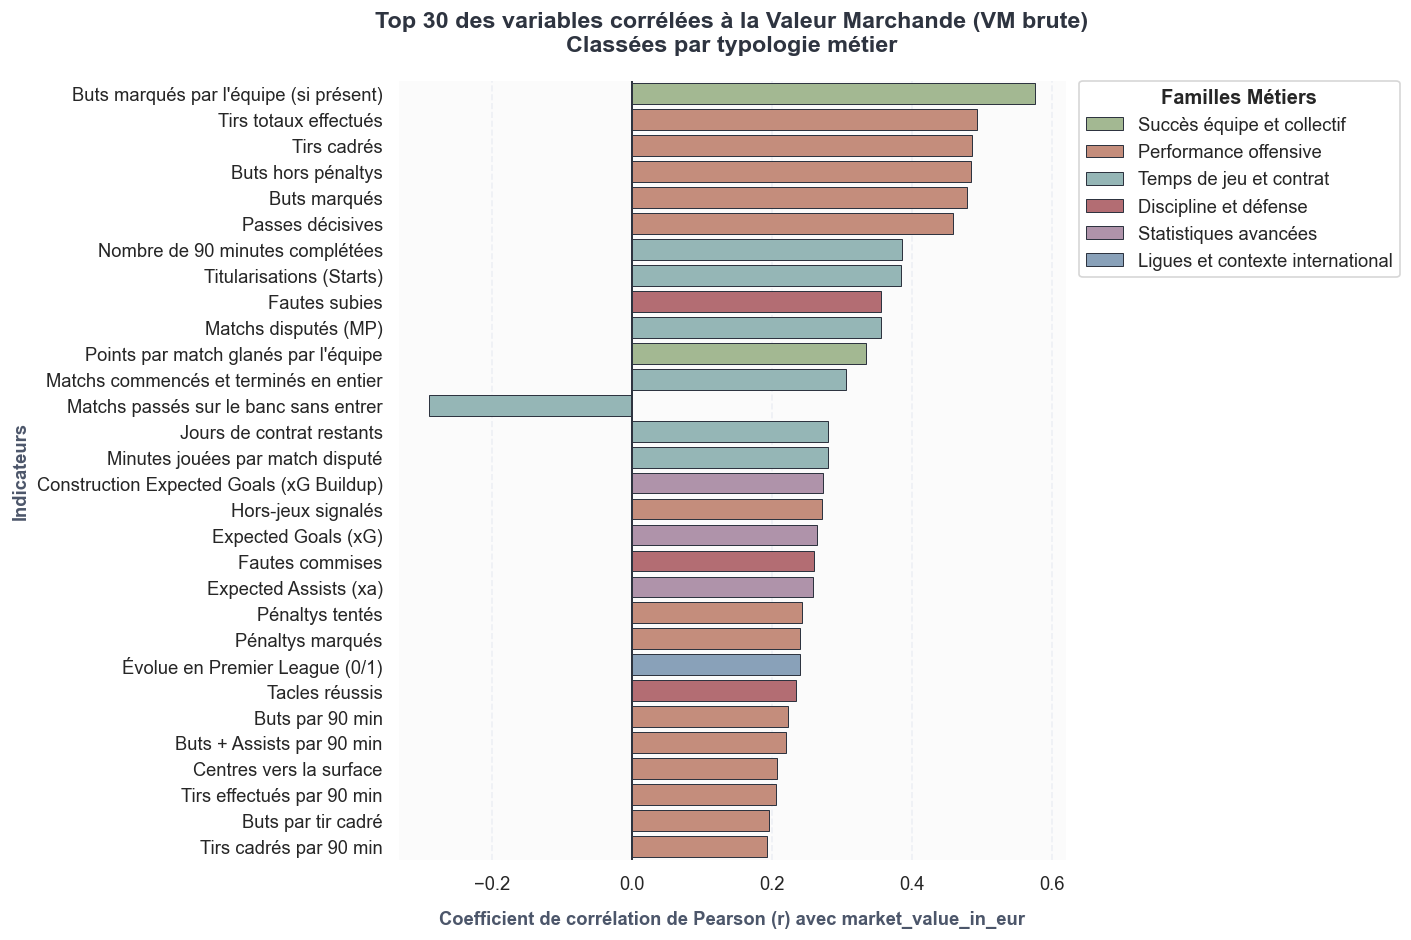

,Variable,Description,Famille,Corr_Cible_Brute
0,Team Success_onG,Buts marqués par l'équipe (si présent),Succès équipe et collectif,0.576
1,Standard_Sh,Tirs totaux effectués,Performance offensive,0.493
2,Standard_SoT,Tirs cadrés,Performance offensive,0.485
3,Performance_G-PK,Buts hors pénaltys,Performance offensive,0.484
4,Performance_Gls,Buts marqués,Performance offensive,0.478
5,Performance_Ast,Passes décisives,Performance offensive,0.459
6,Playing Time_90s,Nombre de 90 minutes complétées,Temps de jeu et contrat,0.386
7,Playing Time_Starts,Titularisations (Starts),Temps de jeu et contrat,0.384
8,Performance_Fld,Fautes subies,Discipline et défense,0.355
9,Playing Time_MP,Matchs disputés (MP),Temps de jeu et contrat,0.355


In [21]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base, target_col=TARGET, top_n=30)

# On affiche le tableau propre sous le graphique
display(tableau_importance)